Why Use Decision Trees?
Advantages

✅ Easy to understand

✅ No Feature Scaling Required

✅ Handles Non-Linear Data

✅ Works for Classification & Regression

✅ Feature Importance Available

Disadvantages

❌ Overfitting

❌ Sensitive to Small Data Changes

❌ Large Trees become Complex

1. Decision Tree Classifier : 

examples:

Churn Prediction
Fraud Detection
Disease Prediction


2. Decision Tree Regressor:

Examples:

House Price Prediction
Salary Prediction

Employee Attrition Prediction

target : Attrition

0 = Stay
1 = Leave


1. importing libs

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

Cell 2 Generate Dataset

In [2]:
np.random.seed(42)

n = 3000

age = np.random.randint(21, 60, n)

salary = np.random.randint(20000, 150000, n)

experience = np.random.randint(0, 20, n)

projects = np.random.randint(1, 15, n)

overtime = np.random.randint(0, 2, n)

job_satisfaction = np.random.randint(1, 6, n)

attrition = (
    (salary < 50000).astype(int)
    + (overtime == 1).astype(int)
    + (job_satisfaction <= 2).astype(int)
)

attrition = (attrition >= 2).astype(int)

df = pd.DataFrame({
    "Age": age,
    "Salary": salary,
    "Experience": experience,
    "Projects": projects,
    "Overtime": overtime,
    "JobSatisfaction": job_satisfaction,
    "Attrition": attrition
})

print(df)

      Age  Salary  Experience  Projects  Overtime  JobSatisfaction  Attrition
0      59   38951          10         7         1                2          1
1      49   21307          16         7         0                4          0
2      35  100388          16         6         0                3          0
3      28  110768           3         3         1                4          0
4      41   55428           7        14         1                2          1
...   ...     ...         ...       ...       ...              ...        ...
2995   44   43527          12         8         1                1          1
2996   39  131483          10        11         0                4          0
2997   57   38443          18         4         0                5          0
2998   59   36524           2        12         0                3          0
2999   41  136477          14         7         0                3          0

[3000 rows x 7 columns]


Cell 3 EDA

In [7]:
print(df.shape)
print("\n",df.info(),"\n",df.describe(),"\n",df["Attrition"].value_counts())

(3000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              3000 non-null   int64
 1   Salary           3000 non-null   int64
 2   Experience       3000 non-null   int64
 3   Projects         3000 non-null   int64
 4   Overtime         3000 non-null   int64
 5   JobSatisfaction  3000 non-null   int64
 6   Attrition        3000 non-null   int64
dtypes: int64(7)
memory usage: 164.2 KB

 None 
                Age         Salary   Experience     Projects     Overtime  \
count  3000.000000    3000.000000  3000.000000  3000.000000  3000.000000   
mean     40.327000   84391.123000     9.595000     7.488333     0.506333   
std      11.302182   37453.134285     5.763915     4.074972     0.500043   
min      21.000000   20112.000000     0.000000     1.000000     0.000000   
25%      31.000000   51501.000000     5.000000     4.000000     0.0000

Cell 4 Correlation

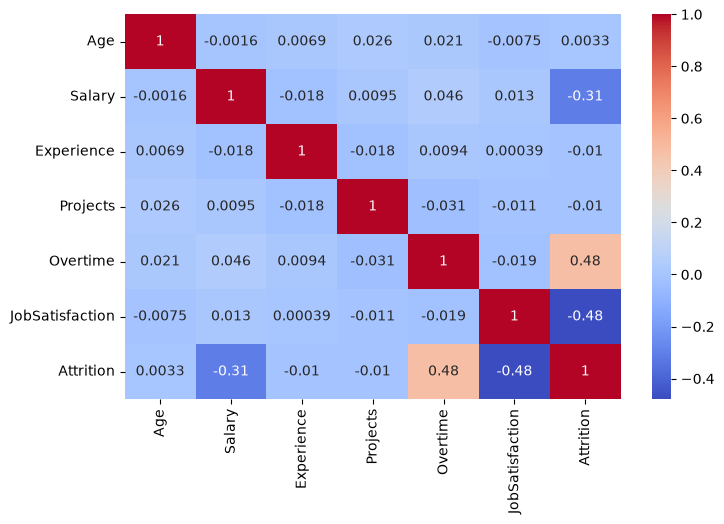

In [8]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Cell 5 Features & Target

In [9]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print(X,"\n",y)

      Age  Salary  Experience  Projects  Overtime  JobSatisfaction
0      59   38951          10         7         1                2
1      49   21307          16         7         0                4
2      35  100388          16         6         0                3
3      28  110768           3         3         1                4
4      41   55428           7        14         1                2
...   ...     ...         ...       ...       ...              ...
2995   44   43527          12         8         1                1
2996   39  131483          10        11         0                4
2997   57   38443          18         4         0                5
2998   59   36524           2        12         0                3
2999   41  136477          14         7         0                3

[3000 rows x 6 columns] 
 0       1
1       0
2       0
3       0
4       1
       ..
2995    1
2996    0
2997    0
2998    0
2999    0
Name: Attrition, Length: 3000, dtype: int64


Cell 6 Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\n",X_train,"\n",X_test,"\n",y_train,"\n",y_test)


       Age  Salary  Experience  Projects  Overtime  JobSatisfaction
2621   39   96996          19         2         0                5
2526   30   30703           1         9         1                3
2342   40   59519          17        11         1                4
429    53   48172           9         1         0                5
2792   26  134527          17        13         1                2
...   ...     ...         ...       ...       ...              ...
2899   29  117512           2         8         0                3
994    31   20174          19        14         1                3
2974   43  120649           1        14         1                2
1870   27   55618           6        13         1                4
186    58   76699           2         7         1                2

[2100 rows x 6 columns] 
       Age  Salary  Experience  Projects  Overtime  JobSatisfaction
2585   57   76683          13        10         1                2
419    40   46672           5    

Cell 7 Train Model

In [12]:
model = DecisionTreeClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Cell 8 Prediction

In [13]:
y_pred = model.predict(X_test)

In [14]:
print(y_pred)

[1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0
 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 1 0 1 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0
 0 0 0 0 1 1 1 1 0 1 1 0 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 1 1 1 1 0 1
 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 0
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1
 1 1 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 0 1 1 0 0 1 0
 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1
 0 0 1 0 1 0 1 1 0 0 1 0 

Cell 9 Metrics

In [15]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1:",
      f1_score(y_test, y_pred))

Accuracy: 0.9988888888888889
Precision: 0.9965753424657534
Recall: 1.0
F1: 0.9982847341337907


Cell 10 Confusion Matrix

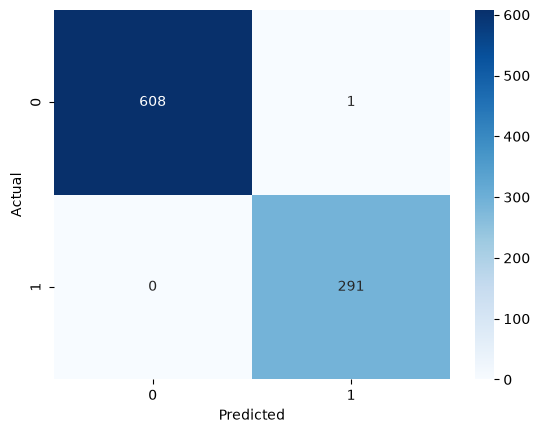

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


Cell 11 Classification Report

In [20]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      1.00      1.00       291

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



Cell 12 Feature Importance

Decision Trees give feature importance.

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(importance)

           Feature  Importance
4         Overtime    0.453886
5  JobSatisfaction    0.284789
1           Salary    0.261325
0              Age    0.000000
2       Experience    0.000000
3         Projects    0.000000


Cell 13 Visualize Tree

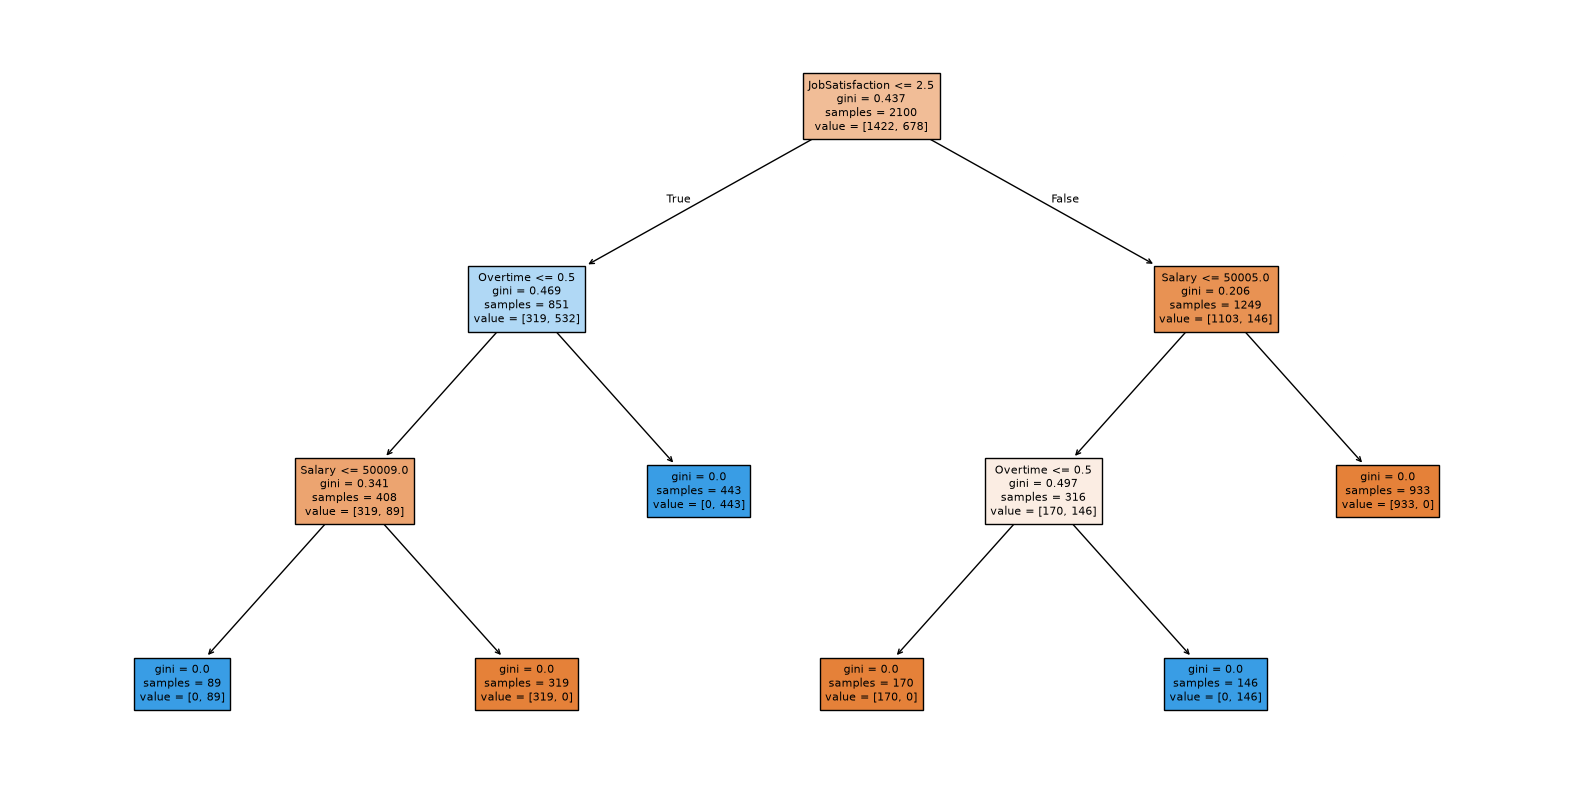

In [22]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)

plt.show()

Cell 14 Hyperparameter Tuning

In [23]:
params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


Cell 15 Best Model

In [24]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       609
           1       1.00      1.00      1.00       291

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900



Cell 16 Predict New Employee

In [25]:
new_employee = pd.DataFrame({
    "Age": [28],
    "Salary": [35000],
    "Experience": [2],
    "Projects": [10],
    "Overtime": [1],
    "JobSatisfaction": [1]
})

prediction = best_model.predict(
    new_employee
)

probability = best_model.predict_proba(
    new_employee
)

print("Prediction:", prediction[0])

print("Probability:", probability[0])


Prediction: 1
Probability: [0. 1.]


another employee

In [26]:
new_employee = pd.DataFrame({
    "Age": [40],
    "Salary": [120000],
    "Experience": [15],
    "Projects": [5],
    "Overtime": [0],
    "JobSatisfaction": [5]
})

print(best_model.predict(new_employee))
print(best_model.predict_proba(new_employee))

[0]
[[1. 0.]]


More Interesting Example

Try an employee near the decision boundary:

In [28]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Salary": [55000],
    "Experience": [4],
    "Projects": [8],
    "Overtime": [1],
    "JobSatisfaction": [3]
})

print(best_model.predict(new_employee))
print(best_model.predict_proba(new_employee))

[0]
[[1. 0.]]
